## CMPINF 2100 Week 02
### Simulating the average
## Overview


In [1]:
import random

we are going to import matplotlib.pyplot to vizualize the average

In [2]:
import matplotlib.pyplot as plt

In [3]:
%whos

Variable   Type      Data/Info
------------------------------
plt        module    <module 'matplotlib.pyplo<...>es/matplotlib/pyplot.py'>
random     module    <module 'random' from '/o<...>lib/python3.8/random.py'>


## Uniform random numbers

In [4]:
random.seed(2100)
xu_1000 = [random.random() for _ in range(1000)]
xy_100000 = [random.random() for _ in range(100000)]

visualize the distribution using a histogram

In [5]:
xu_1000[-1]

0.8964477774412416

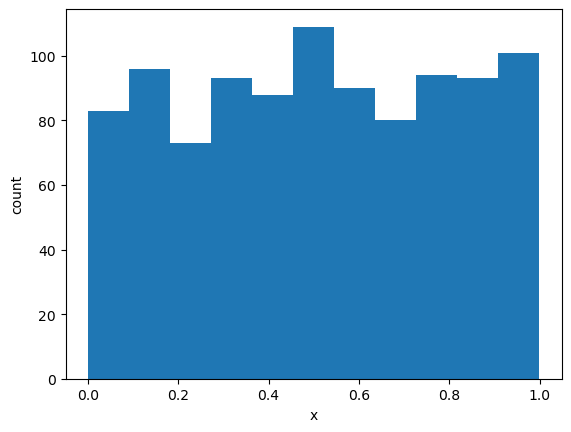

In [6]:
plt.hist( xu_1000, bins=11 ) 
plt.xlabel('x')
plt.ylabel('count')
plt.show()

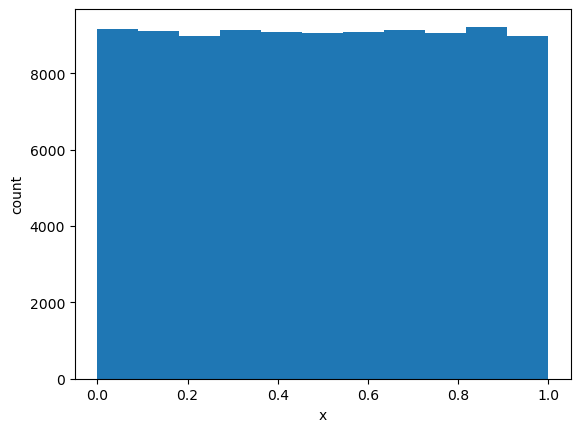

In [7]:
plt.hist( xy_100000, bins=11 ) 
plt.xlabel('x')
plt.ylabel('count')
plt.show()

In [8]:
def my_avg(x):
    return sum(x)/len(x)
my_avg( [random.random() for _ in range(1000000)])

0.4996970006651433

In [9]:
round(my_avg( [random.random() for _ in range(1000000)]), 1)

0.5

what we we get only 5 samples

In [10]:
random.seed(2100)
print(my_avg( [random.random() for _ in range(5)]))
print(my_avg( [random.random() for _ in range(5)]))
print(my_avg( [random.random() for _ in range(5)]))

0.3938655785843951
0.5587010971306385
0.5951333231565


### Simulate the variability of the average
* generate a sequence of random numbers from an assumed distribution 
* calculate the avg given that sequence

In [11]:
def gen_sample_calc_avg(N):
    """
    Assuming that we are generating values from a uniform distribution between 0 and 1
    """
    return my_avg( [random.random() for _ in range(N)] )

In [12]:
random.seed(2100)
xbar_sim_N05_R1000 = [gen_sample_calc_avg(5) for _ in range(1000)]

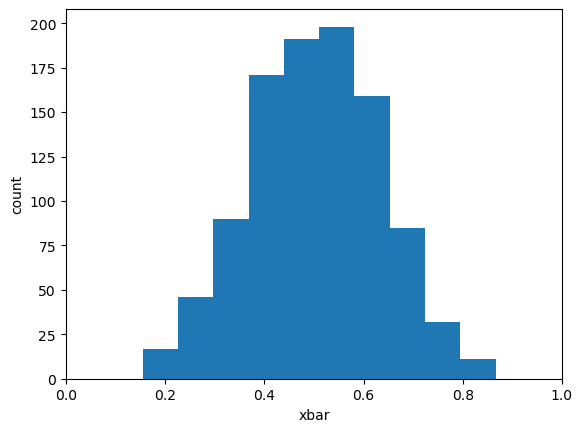

In [13]:
plt.hist(xbar_sim_N05_R1000)
plt.xlabel("xbar")
plt.ylabel("count")
plt.xlim(0,1)
plt.show()

In [14]:
my_avg(xbar_sim_N05_R1000)

0.502647095657702

Let us replicate it but with 10000 times

In [15]:
random.seed(2100)
xbar_sim_N05_R10000 = [gen_sample_calc_avg(5) for _ in range(10000)]

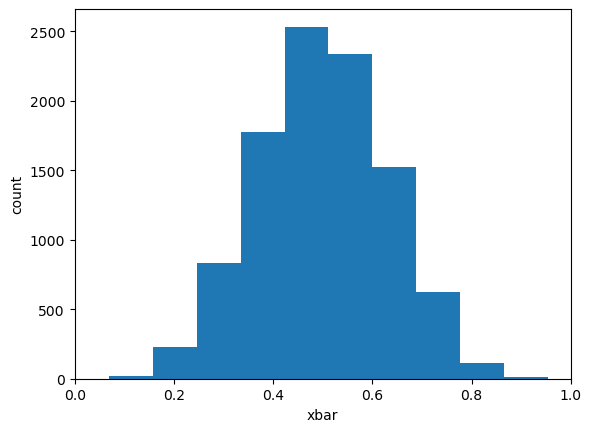

In [16]:
plt.hist(xbar_sim_N05_R10000)
plt.xlabel("xbar")
plt.ylabel("count")
plt.xlim(0,1)
plt.show()

In [17]:
my_avg(xbar_sim_N05_R10000)

0.4991771248488468

Let's do it for just 11

In [18]:
random.seed(2100)
xbar_sim_N05_R0011 = [gen_sample_calc_avg(5) for _ in range(11)]

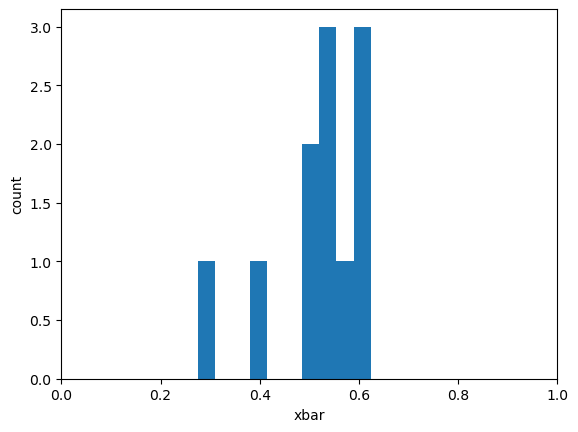

In [19]:
plt.hist(xbar_sim_N05_R0011)
plt.xlabel("xbar")
plt.ylabel("count")
plt.xlim(0,1)
plt.show()

In [20]:
number_replications = [5 * (2** ix) for ix in range(12)]

In [21]:
number_replications

[5, 10, 20, 40, 80, 160, 320, 640, 1280, 2560, 5120, 10240]

In [22]:
for index_in_sequence, value_in_sequence in enumerate(number_replications):
    print(index_in_sequence, value_in_sequence)

0 5
1 10
2 20
3 40
4 80
5 160
6 320
7 640
8 1280
9 2560
10 5120
11 10240


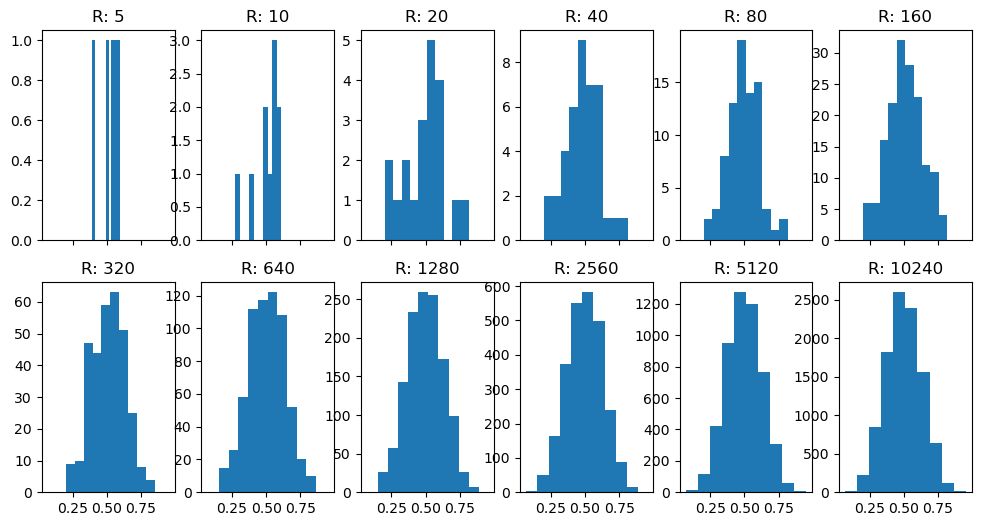

In [23]:
fig, axs = plt.subplots(2,6, figsize=(12,6), sharex=True, sharey=False)
axs = axs.ravel()
for i, nr in enumerate(number_replications):
    random.seed(2100)
    axs[i].hist([gen_sample_calc_avg(5) for _ in range(nr)])
    axs[i].set_title('R: %d' % (nr))

Bell curve is another name for gausian distribution or normal distribution
Central Limit Theorem
The VARIANCE is a statistics that descrives VARIATION or VARIABILITY!!!
$$ s^2 = \frac{1}{N-1} \sum_{n=1}^{N} \left( \left(x_n - \bar{x}\right)^2 \right)$$

Break down the formula for the sample variance into 6 main steps:
* calculate the sample average
* calculate the DEVIATION(difference) of each measurement from the AVERAGE
* Square the deviation
* Sum the squared deviation across all measurements
* Divide the SUM of the squared deviation by the length munus 1
the VARIANCE is the MEAN squared deviation from the average!!!!

In [24]:
def my_variance(x):
    xbar = my_avg(x)
    squared_deviation = [ (xn - xbar) ** 2 for xn in x ]
    return sum(squared_deviation) /( len(x) -1 )

In [25]:
print( my_variance([1,2,3]) )

1.0


In [26]:
print( my_variance([5,10,15]) )

25.0


In [27]:
my_variance(xbar_sim_N05_R10000)

0.016879961620988607

the standard deviation is the half width of the bell curve
the standard deviation is the SQUARE ROOT of the variance
Or, the variance is the standard deviation SQUARED!!!

In [28]:
def my_sd(x):
    return my_variance(x) ** 0.5

In [29]:
my_sd(xbar_sim_N05_R10000)

0.12992290645220575

In [30]:
my_avg(xbar_sim_N05_R10000)

0.4991771248488468

### How can we use this???


In [31]:
sample_size_study = [ 3 * (2 ** ix) for ix in range(15) ]

In [32]:
sample_size_study

[3, 6, 12, 24, 48, 96, 192, 384, 768, 1536, 3072, 6144, 12288, 24576, 49152]

Let's replicate 2500 times calculationg the average from a sample size to ensure we rougly have a normal distribution for normal avarage

In [33]:
random.seed(2100)
study_sd_vs_samplesize = [ my_sd( [gen_sample_calc_avg(n) for _ in range(2500)] ) for n in sample_size_study]

Show the SD

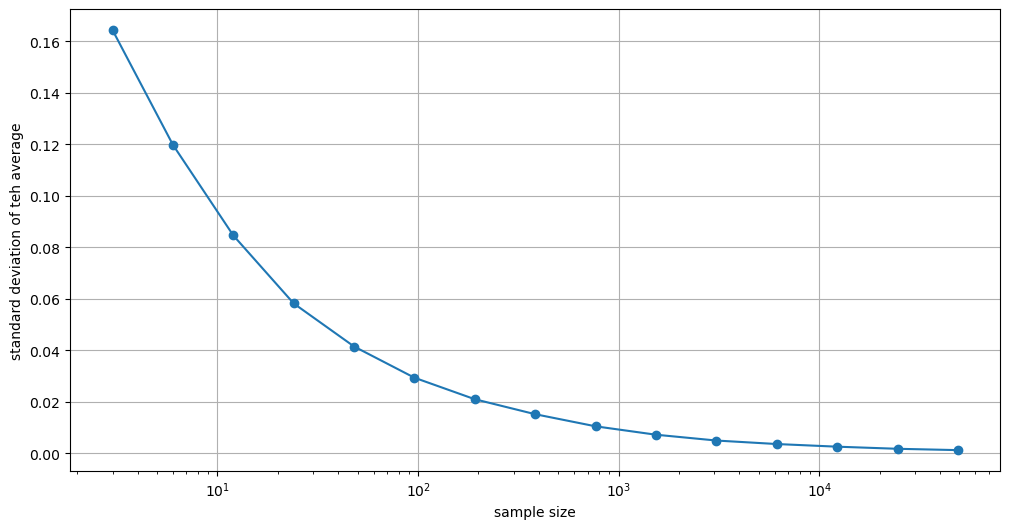

In [34]:
fig, ax = plt.subplots(figsize=(12,6))
ax.plot( sample_size_study, study_sd_vs_samplesize, '-o')
ax.set_xscale('log')
ax.set_xlabel('sample size')
ax.set_ylabel('standard deviation of teh average')
ax.grid(True)
plt.show()

the standard deviation on the average is Extremely important
the SD on the average decreases as the sample size decreases is very imp
the SD on the avg has a special name STANDARD ERROR ON THE MEAN (SEM)
we are less confident when the smaple size is small but  we are more confident when sample size is bigger

## Theory
the Standard error of the Mean (SEM) has a FORMULA!!!
SEM = (standard deviation)/(square root of the number of samples)
In math...
$$ \mathrm(SEM) = \frac{\sigma}{\sqrt(N)} $$
The $\sigma$ is the standard deviation of the measurements. We are currently using a random number generator that generates UNIFORM random numbers. There is a KNOWN fomulat for VARIANCE of a UNIFORM distribution.

Let's assuem the LOWER bound is $a$ and the UPPER bound is $b$. The formula for the VARIANCE of a UNIFORM distribution is:
$$ Variance = \frac{1}{12} \left( b - a \right)^2 $$
We have worked with a uniform between 0 and 1, thus the Variance is:
$$ Variance = \frac{1}{12} $$
The Standard deviation is the square root of the variance:
$$ \sigma = \frac{1}{\sqrt{12}} $$
The SEM for OUR example is then:
$$ \mathrm{SEM} = \frac{1}{\sqrt(12\times N }$$
OR
$$ \mathrm{SEM} = \left( \frac{ 1/12} {N} \right)^{0.5} $$
Let's use this formula and compare the THEORETICAL SEM to OUR SIMULATION RESULTS

In [35]:
sem_theory = [ ( (1/12)/n ) **0.5 for n in sample_size_study ]

In [36]:
len(sem_theory)

15

In [37]:
len(sample_size_study)

15

In [38]:
len( study_sd_vs_samplesize)

15

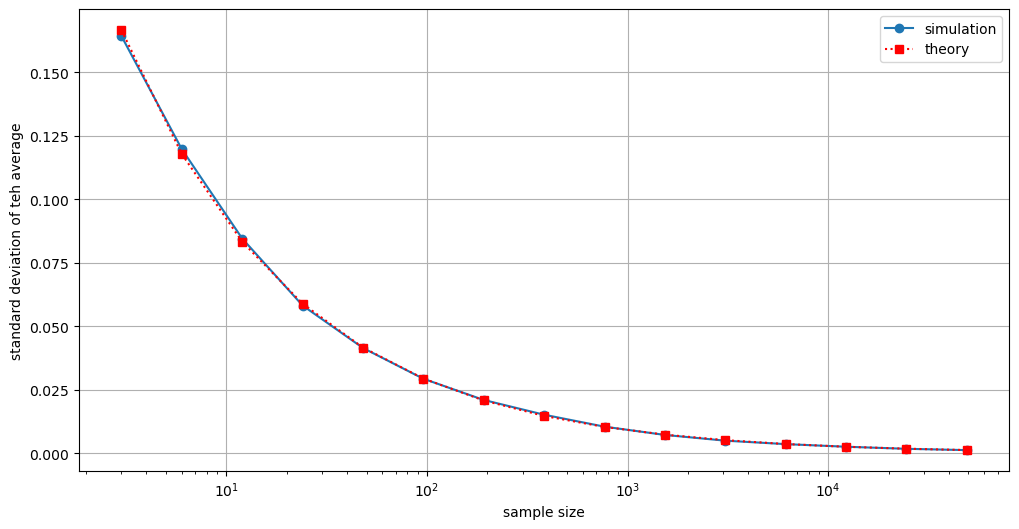

In [39]:
fig, ax = plt.subplots(figsize=(12,6))
ax.plot( sample_size_study, study_sd_vs_samplesize, '-o', label='simulation')
ax.plot(sample_size_study, sem_theory, ':sr', label='theory')
ax.set_xscale('log')
ax.set_xlabel('sample size')
ax.set_ylabel('standard deviation of teh average')
ax.grid(True)
ax.legend()
plt.show()

### Using other distributions
we can repeat this exercise by generating random number from other distributions

In [40]:
 random.gauss( mu = 250, sigma = 20)

228.2934387071578

In [41]:
 random.gauss( mu = 250, sigma = 2)

250.4944176547876

We can express our CONFIDENCE using the CLT and the standard error!!! The CONFIDENCE INTERVAL represents where you anticipate the average to be!!!
The most common type of confidence interval is the 95% confidence interval whihc represents there's a 95% chance the average is somoewhere inside theat interval!!!
The 95% confidence interval is approximately equal to the sample average +/- 2 time sthe SEM !!!
$$ 95\% \ \mathrm{confidence} \ \mathrm{interval} = \left(\ \mathrm{average}) - 2 \times \mathrm{SEM}, \mathrm{average} + 2 \times \mathrm{SEM} \right) $$

In [42]:
random.seed(2100)
yu = [ random.random() for _ in range(5) ]

In [43]:
yu

[0.764021138054951,
 0.4692037101382426,
 0.09010549233469012,
 0.08980190601697957,
 0.5561956463771123]

In [44]:
sample_sd = my_sd( yu )

In [45]:
sample_sd

0.29739154752454966

In [46]:
sem = sample_sd / (len(yu)**0.5)

In [47]:
sem

0.13299754323975047

In [48]:
sample_avg = my_avg(yu)

In [49]:
sample_avg

0.3938655785843951

In [50]:
conf_int = ( sample_avg - 2 * sem, sample_avg + 2 * sem)

In [51]:
conf_int

(0.12787049210489415, 0.6598606650638961)

In [52]:
conf_int[1] - conf_int[0]

0.531990172959002

What if we could observe 1000 measurements????

In [53]:
random.seed(2100)
zu = [ random.random() for _ in range(1000) ]

In [54]:
sample_avg_z = my_avg( zu )

In [55]:
sample_avg_z

0.5122667139741787

In [56]:
sample_sd_z = my_sd( zu )

In [57]:
sample_sd_z

0.2882658778232974

In [58]:
sem_z = sample_sd_z / (len(zu)**0.5)

In [59]:
sem_z

0.009115767456294407

In [60]:
(sample_avg_z - 2 * sem_z, sample_avg_z + 2 * sem_z)

(0.49403517906158984, 0.5304982488867674)

stadard error decreases with the increase in sample size